# Part A: Data preprocessing 

0. Imports and configs 


In [20]:
import os
import random
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter
import tensorflow as tf

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

IMAGES_DIR = Path("data/images/Images")
ANNOTATIONS_DIR = Path("data/annotations/Annotation")

1. Functions 

In [21]:
def parse_annotation(annotation_path):
    """Parse XML annotation and return bounding box normalized to [0, 1]. 0 is top left and 1 is bottom right"""
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    obj = root.find("object")
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text) / width
    ymin = int(bndbox.find("ymin").text) / height
    xmax = int(bndbox.find("xmax").text) / width
    ymax = int(bndbox.find("ymax").text) / height

    return [xmin, ymin, xmax, ymax]


def load_and_preprocess(image_path, label, bbox):
    """Load image, decodes the jpeg, resize, normalize, and return as tensor"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {"class_output": label, "bbox_output": bbox}


def build_dataset(paths, labels, bboxes, shuffle=False):
    """Takes in the image paths, labels, and bounding boxes and returns a tf.data.Dataset 
    where the first column is the imagepath  and the second column is the label and the third column is the bounding box"""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels, bboxes)) #creates a dataset from the input tensors
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE) #applies the load_and_preprocess function to each element of the dataset
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) #batches the dataset and prefetches the next batch
    return ds


def plot_breed_distribution(y_train, y_val, y_test, label_to_breed, num_classes):
    """Grouped horizontal bar chart of samples per breed across splits."""
    breed_names = [label_to_breed[i] for i in range(num_classes)]
    train_counts = [np.sum(y_train == i) for i in range(num_classes)]
    val_counts   = [np.sum(y_val == i)   for i in range(num_classes)]
    test_counts  = [np.sum(y_test == i)  for i in range(num_classes)]

    y_pos = np.arange(num_classes)
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.barh(y_pos - bar_h, train_counts, bar_h, label=f"Train ({len(y_train)})", color="#4c72b0")
    ax.barh(y_pos,         val_counts,   bar_h, label=f"Val ({len(y_val)})",     color="#55a868")
    ax.barh(y_pos + bar_h, test_counts,  bar_h, label=f"Test ({len(y_test)})",   color="#c44e52")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(breed_names, fontsize=9)
    ax.set_xlabel("Number of Images")
    ax.set_title("Samples per Breed by Split")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


2. Downlaoding the data, donwloads only once

#set up kaggle credential for download


In [22]:


DATA_DIR = Path("data")

if not DATA_DIR.exists():
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "jessicali9530/stanford-dogs-dataset", "--unzip", "-p", "./data"],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print("Dataset downloaded and extracted to ./data")
    else:
        stderr = (result.stderr or "").strip()
        missing_auth = (
            "KeyError: 'username'" in stderr
            or "Could not find kaggle.json" in stderr
            or "credentials" in stderr.lower()
        )

        if missing_auth:
            print("Kaggle credentials were not found on this machine.")
            print("Each user should configure their own Kaggle account locally:")
            print("  1) Create ~/.kaggle/kaggle.json with your own username and API key")
            print("  2) Run: chmod 600 ~/.kaggle/kaggle.json")
            print("  3) Re-run this cell")
        else:
            print(f"Download failed:\n{stderr}")
else:
    print("Dataset already exists at ./data")

Dataset already exists at ./data


2. Breed selection and label mapping

In [23]:
SELECTED_BREEDS = [
    "n02085620-Chihuahua",
    "n02086240-Shih-Tzu",
    "n02087394-Rhodesian_ridgeback",
    "n02088364-beagle",
    "n02089973-English_foxhound",
    "n02091032-Italian_greyhound",
    "n02092339-Weimaraner",
    "n02093256-Staffordshire_bullterrier",
    "n02094433-Yorkshire_terrier",
    "n02096585-Boston_bull",
    "n02097047-miniature_schnauzer",
    "n02099601-golden_retriever",
    "n02099712-Labrador_retriever",
    "n02100877-Irish_setter",
    "n02102318-cocker_spaniel",
    "n02105855-Shetland_sheepdog",
    "n02106166-Border_collie",
    "n02106382-Bouvier_des_Flandres",
    "n02106550-Rottweiler",
    "n02106662-German_shepherd",
    "n02107142-Doberman",
    "n02107683-Bernese_mountain_dog",
    "n02108089-boxer",
    "n02108915-French_bulldog",
    "n02109047-Great_Dane",
    "n02109525-Saint_Bernard",
    "n02110185-Siberian_husky",
    "n02110958-pug",
    "n02111889-Samoyed",
    "n02112018-Pomeranian",
]

breed_to_label = {breed: i for i, breed in enumerate(SELECTED_BREEDS)} #labels are numerical class
label_to_breed = {i: breed.split("-", 1)[1] for i, breed in enumerate(SELECTED_BREEDS)}
NUM_CLASSES = len(SELECTED_BREEDS)

print(f"Selected {NUM_CLASSES} breeds:")
for i, breed in label_to_breed.items():
    print(f"  {i:2d}: {breed}")

Selected 30 breeds:
   0: Chihuahua
   1: Shih-Tzu
   2: Rhodesian_ridgeback
   3: beagle
   4: English_foxhound
   5: Italian_greyhound
   6: Weimaraner
   7: Staffordshire_bullterrier
   8: Yorkshire_terrier
   9: Boston_bull
  10: miniature_schnauzer
  11: golden_retriever
  12: Labrador_retriever
  13: Irish_setter
  14: cocker_spaniel
  15: Shetland_sheepdog
  16: Border_collie
  17: Bouvier_des_Flandres
  18: Rottweiler
  19: German_shepherd
  20: Doberman
  21: Bernese_mountain_dog
  22: boxer
  23: French_bulldog
  24: Great_Dane
  25: Saint_Bernard
  26: Siberian_husky
  27: pug
  28: Samoyed
  29: Pomeranian


3. GOes through each image, the image is added to img_paths list, the bb are extracted and normalized and added into the bboxes list, and the label(which is the dog bread) is added to the labels list. 

In [24]:
image_paths = []  #array of image paths
labels = [] #array of labels which is the dog bread
bboxes = [] #array of bounding boxes, each element is a list of 4 numbers [xmin, ymin, xmax, ymax]
skipped = 0 #number of images skipped



for breed_folder in SELECTED_BREEDS:
    label = breed_to_label[breed_folder]
    img_dir = IMAGES_DIR / breed_folder
    ann_dir = ANNOTATIONS_DIR / breed_folder

    for img_file in sorted(img_dir.glob("*.jpg")):
        ann_file = ann_dir / img_file.stem
        if not ann_file.exists():
            skipped += 1
            continue
        try:
            bbox = parse_annotation(ann_file) # function to parse the annotation and return the normalized bounding box for the gicen image
            image_paths.append(str(img_file))
            labels.append(label)
            bboxes.append(bbox)
        except Exception:
            skipped += 1

image_paths = np.array(image_paths)
labels = np.array(labels)
bboxes = np.array(bboxes, dtype=np.float32)

print(f"Total samples: {len(image_paths)} (skipped {skipped})")
print(f"Labels shape: {labels.shape}, Bboxes shape: {bboxes.shape}")
print(f"\nSamples per breed:")
counts = Counter(labels)
for lbl in sorted(counts):
    print(f"  {label_to_breed[lbl]:30s}: {counts[lbl]}")

Total samples: 5116 (skipped 0)
Labels shape: (5116,), Bboxes shape: (5116, 4)

Samples per breed:
  Chihuahua                     : 152
  Shih-Tzu                      : 214
  Rhodesian_ridgeback           : 172
  beagle                        : 195
  English_foxhound              : 157
  Italian_greyhound             : 182
  Weimaraner                    : 160
  Staffordshire_bullterrier     : 155
  Yorkshire_terrier             : 164
  Boston_bull                   : 182
  miniature_schnauzer           : 154
  golden_retriever              : 150
  Labrador_retriever            : 171
  Irish_setter                  : 155
  cocker_spaniel                : 159
  Shetland_sheepdog             : 157
  Border_collie                 : 150
  Bouvier_des_Flandres          : 150
  Rottweiler                    : 152
  German_shepherd               : 152
  Doberman                      : 150
  Bernese_mountain_dog          : 218
  boxer                         : 151
  French_bulldog           

4. Stratified split: 70% train, 15% validation, 15% test
stratify=labels ensures each breed has the same proportion in every split

In [25]:
X_train, X_temp, y_train, y_temp, bbox_train, bbox_temp = train_test_split( #splits into 70% train, and 30% temp
    image_paths, labels, bboxes,
    test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test, bbox_val, bbox_test = train_test_split( #the 30 temp is split into 15% val and 15% test
    X_temp, y_temp, bbox_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

print(f"\nBreed distribution check (first 5 breeds):")
for lbl in range(5):
    name = label_to_breed[lbl]
    tr = np.sum(y_train == lbl)
    va = np.sum(y_val == lbl)
    te = np.sum(y_test == lbl)
    print(f"  {name:25s} -> train={tr}, val={va}, test={te}")

Train:      3581 samples
Validation: 767 samples
Test:       768 samples

Breed distribution check (first 5 breeds):
  Chihuahua                 -> train=106, val=23, test=23
  Shih-Tzu                  -> train=150, val=32, test=32
  Rhodesian_ridgeback       -> train=120, val=26, test=26
  beagle                    -> train=137, val=29, test=29
  English_foxhound          -> train=110, val=24, test=23


5. Breed distribution across each split

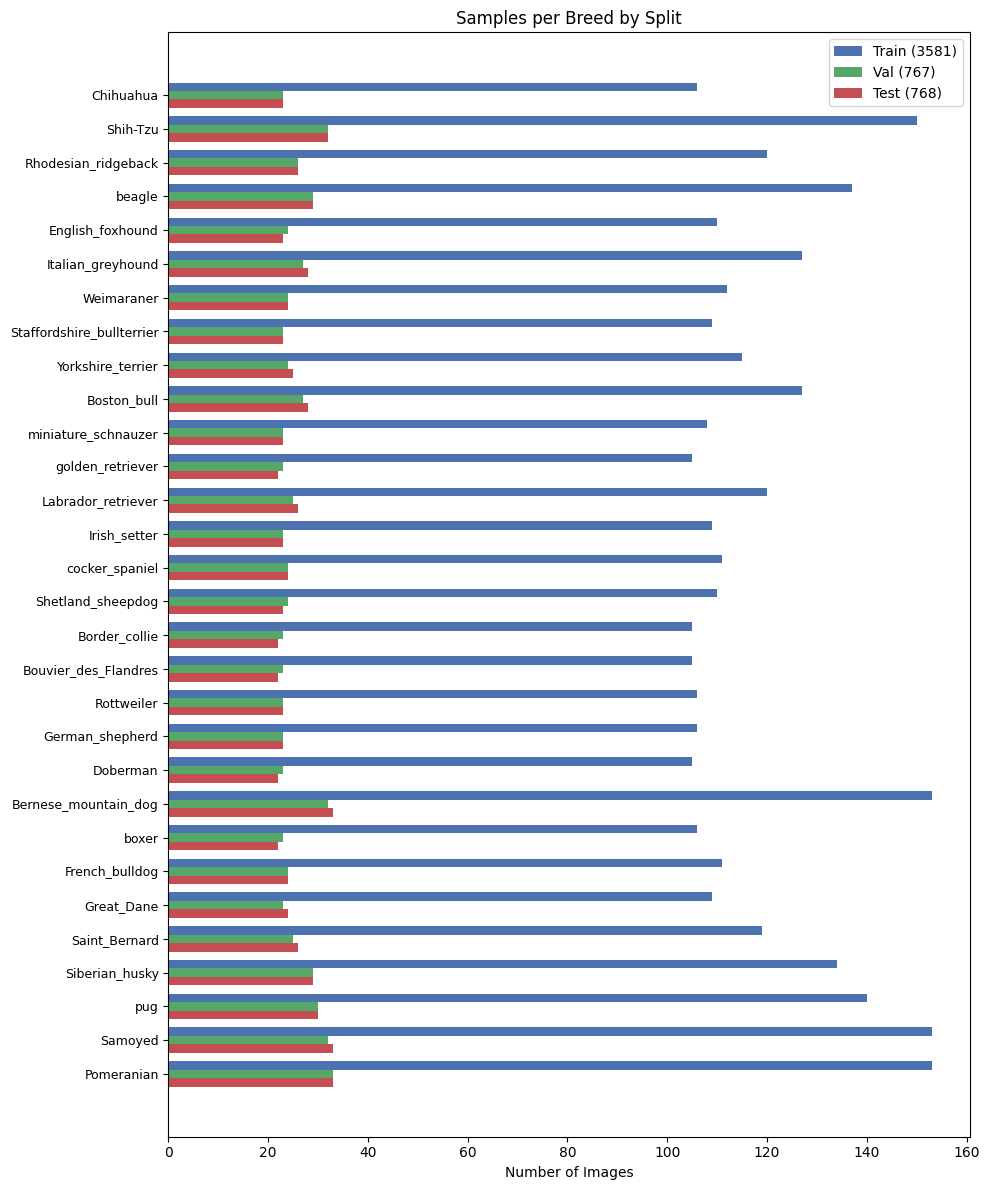

In [26]:
plot_breed_distribution(y_train, y_val, y_test, label_to_breed, NUM_CLASSES)

6. Sanity Check: checking one batch of the trainig to make sure everything is build correctly. 

In [27]:
train_ds = build_dataset(X_train, y_train, bbox_train, shuffle=True) #loads the data into a dataset for training
val_ds = build_dataset(X_val, y_val, bbox_val) #loads the data into a dataset for validation
test_ds = build_dataset(X_test, y_test, bbox_test) #loads the data into a dataset for testing

for images, targets in train_ds.take(1):
    print(f"Image batch shape:  {images.shape}")
    print(f"Labels batch shape: {targets['class_output'].shape}")
    print(f"Bbox batch shape:   {targets['bbox_output'].shape}")
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Image batch shape:  (32, 224, 224, 3)
Labels batch shape: (32,)
Bbox batch shape:   (32, 4)
Pixel range: [0.00, 255.00]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.985953..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1824196..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow w

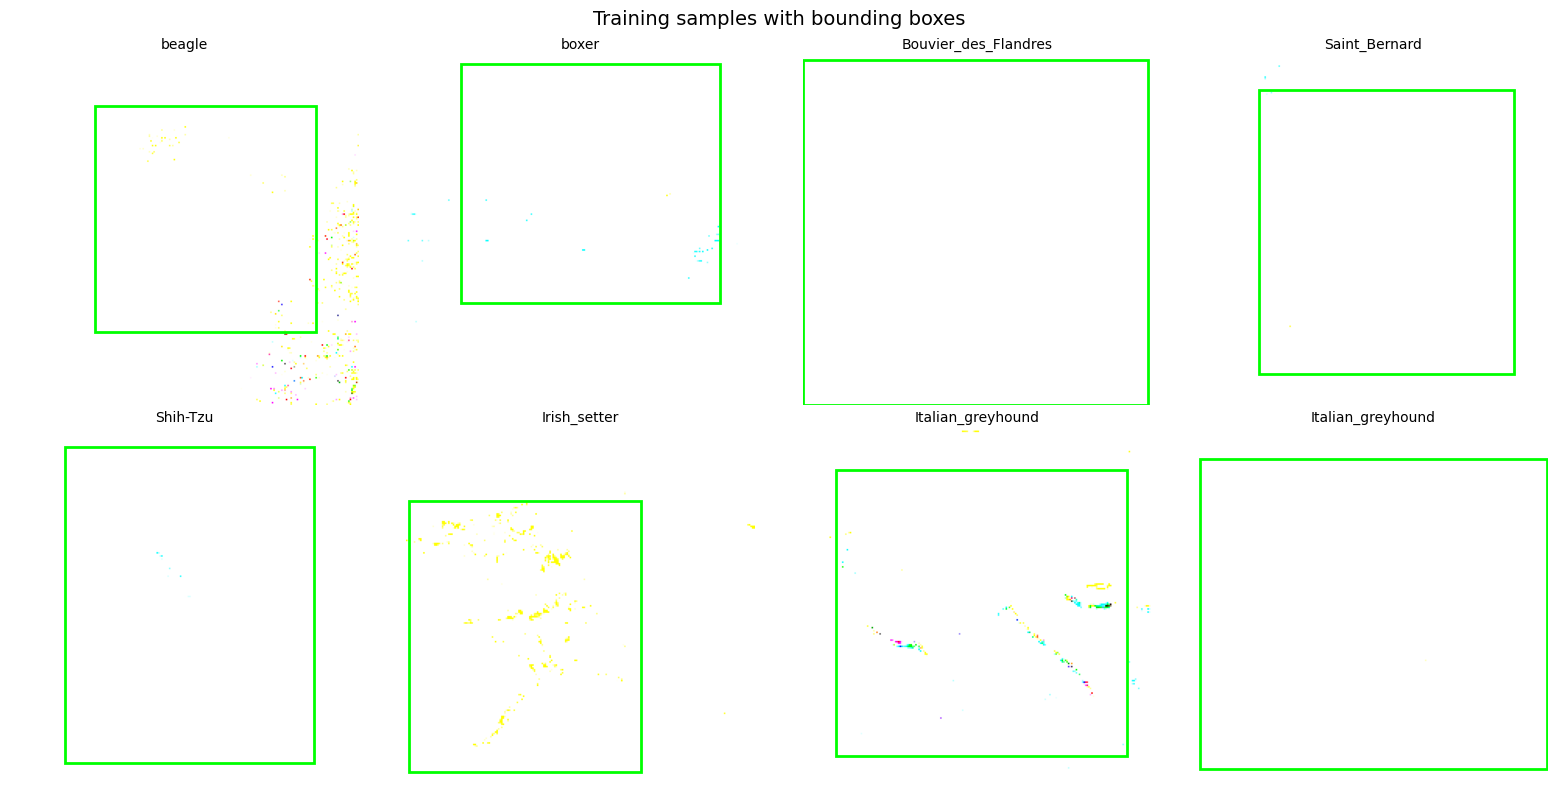

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for images, targets in train_ds.take(1):
    for i in range(8):
        img = images[i].numpy()
        label = targets["class_output"][i].numpy()
        bbox = targets["bbox_output"][i].numpy()

        xmin, ymin, xmax, ymax = bbox
        h, w = IMG_SIZE, IMG_SIZE

        axes[i].imshow(img)
        rect = plt.Rectangle(
            (xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        axes[i].add_patch(rect)
        axes[i].set_title(label_to_breed[label], fontsize=10)
        axes[i].axis("off")

plt.suptitle("Training samples with bounding boxes", fontsize=14)
plt.tight_layout()
plt.show()

# Part B: Model Develpment

In [29]:


# Strip bounding boxes — keep only class labels for this classifier
cls_train_ds = train_ds.map(lambda img, targets: (img, targets["class_output"]))
cls_val_ds   = val_ds.map(lambda img, targets: (img, targets["class_output"]))
cls_test_ds  = test_ds.map(lambda img, targets: (img, targets["class_output"]))

simple_model = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

simple_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 20))

simple_history = simple_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20,
    callbacks=[lr_schedule]
)

Epoch 1/20


/home/omjohnson1/Dog_breed_classification/dog-breed-env/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.0430 - loss: 3.3991 - val_accuracy: 0.0535 - val_loss: 3.3849 - learning_rate: 1.0000e-04
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.0765 - loss: 3.3309 - val_accuracy: 0.0834 - val_loss: 3.2676 - learning_rate: 1.1220e-04
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.1100 - loss: 3.1977 - val_accuracy: 0.1199 - val_loss: 3.1443 - learning_rate: 1.2589e-04
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.1458 - loss: 3.0618 - val_accuracy: 0.1121 - val_loss: 3.0863 - learning_rate: 1.4125e-04
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.1807 - loss: 2.9220 - val_accuracy: 0.1421 - val_loss: 3.0194 - learning_rate: 1.5849e-04
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 18s 162ms/step - accuracy: 0.2287 - loss: 2.7461 - val_accuracy: 0.1512 - val_loss: 2.9891 - learning_rate: 1.7783e-04
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - 

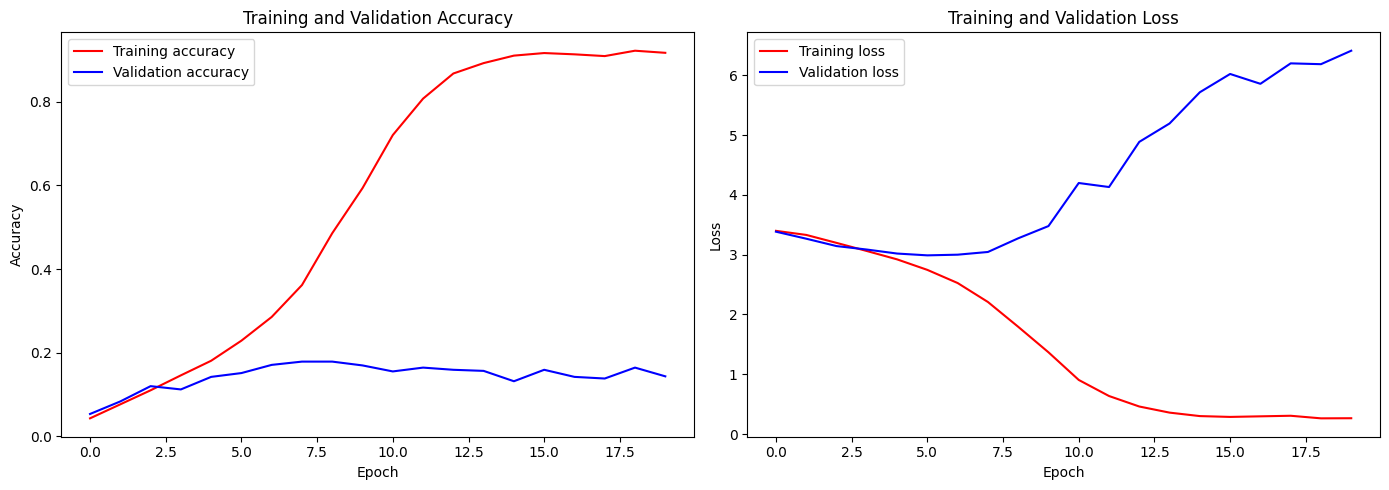

In [30]:
train_acc = simple_history.history['accuracy']
val_acc   = simple_history.history['val_accuracy']
train_loss = simple_history.history['loss']
val_loss   = simple_history.history['val_loss']

epochs = range(len(train_acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, 'r', label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', label='Validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, train_loss, 'r', label='Training loss')
ax2.plot(epochs, val_loss, 'b', label='Validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# ResNet Model

In [31]:
layers = tf.keras.layers
models = tf.keras.models
ResNet50 = tf.keras.applications.ResNet50
preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [33]:
def build_resnet_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)
    x = preprocess_input(x)

    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

In [34]:
resnet_model, resnet_base = build_resnet_model()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

In [35]:
resnet_history_frozen = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=10,
    callbacks=resnet_callbacks
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 92s 744ms/step - accuracy: 0.5471 - loss: 1.6454 - val_accuracy: 0.8840 - val_loss: 0.4067 - learning_rate: 0.0010
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 733ms/step - accuracy: 0.7811 - loss: 0.7160 - val_accuracy: 0.9009 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 731ms/step - accuracy: 0.8260 - loss: 0.5525 - val_accuracy: 0.8983 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 83s 738ms/step - accuracy: 0.8425 - loss: 0.4984 - val_accuracy: 0.9035 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 89s 790ms/step - accuracy: 0.8637 - loss: 0.4355 - val_accuracy: 0.8905 - val_loss: 0.3563 - learning_rate: 0.0010
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 731ms/step - accuracy: 0.8746 - loss: 0.3875 - val_accuracy: 0.9061 - val_loss: 0.3216 - learning_rate: 0.0010
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 83s 738ms/step - accuracy: 0.8

In [36]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-50]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_history_finetune = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=10,
    callbacks=resnet_callbacks
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8699 - loss: 0.4099 - val_accuracy: 0.9205 - val_loss: 0.2859 - learning_rate: 1.0000e-05
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9020 - loss: 0.3123 - val_accuracy: 0.9166 - val_loss: 0.2843 - learning_rate: 1.0000e-05
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9190 - loss: 0.2572 - val_accuracy: 0.9192 - val_loss: 0.2813 - learning_rate: 1.0000e-05
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9232 - loss: 0.2370 - val_accuracy: 0.9205 - val_loss: 0.2835 - learning_rate: 1.0000e-05
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9305 - loss: 0.2076 - val_accuracy: 0.9257 - val_loss: 0.2875 - learning_rate: 1.0000e-05
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9414 - loss: 0.1878 - val_accuracy: 0.9309 - val_loss: 0.2827 - learning_rate: 2.0000e-06
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - acc

In [37]:
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(cls_test_ds)

print(f"ResNet Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet Test Accuracy: {resnet_test_acc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 567ms/step - accuracy: 0.9062 - loss: 0.3148
ResNet Test Loss: 0.3148
ResNet Test Accuracy: 0.9062


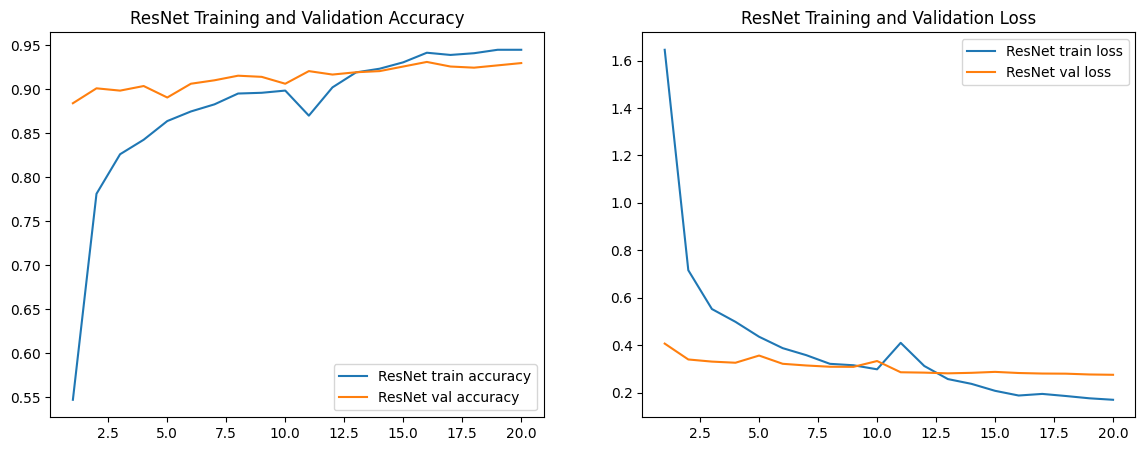

In [38]:
resnet_acc = (
    resnet_history_frozen.history['accuracy']
    + resnet_history_finetune.history['accuracy']
)
resnet_val_acc = (
    resnet_history_frozen.history['val_accuracy']
    + resnet_history_finetune.history['val_accuracy']
)
resnet_loss = (
    resnet_history_frozen.history['loss']
    + resnet_history_finetune.history['loss']
)
resnet_val_loss = (
    resnet_history_frozen.history['val_loss']
    + resnet_history_finetune.history['val_loss']
)

resnet_epochs = range(1, len(resnet_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(resnet_epochs, resnet_acc, label='ResNet train accuracy')
ax1.plot(resnet_epochs, resnet_val_acc, label='ResNet val accuracy')
ax1.set_title('ResNet Training and Validation Accuracy')
ax1.legend()

ax2.plot(resnet_epochs, resnet_loss, label='ResNet train loss')
ax2.plot(resnet_epochs, resnet_val_loss, label='ResNet val loss')
ax2.set_title('ResNet Training and Validation Loss')
ax2.legend()

plt.show()